In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = pd.read_csv(
    "../dataset/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)


df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [57]:
df.info()


df["label"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


label
ham     4825
spam     747
Name: count, dtype: int64

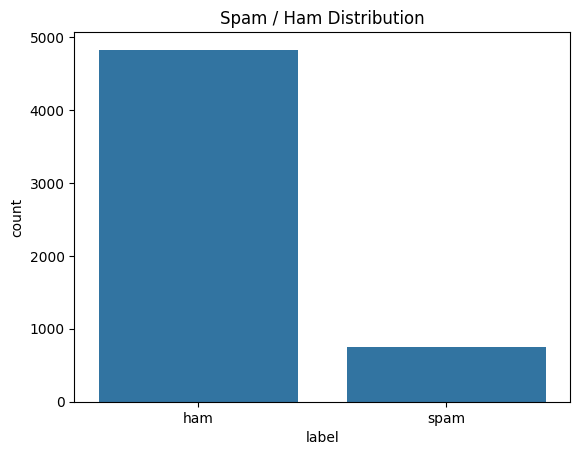

In [58]:
sns.countplot(x=df["label"])
plt.title("Spam / Ham Distribution")
plt.show()

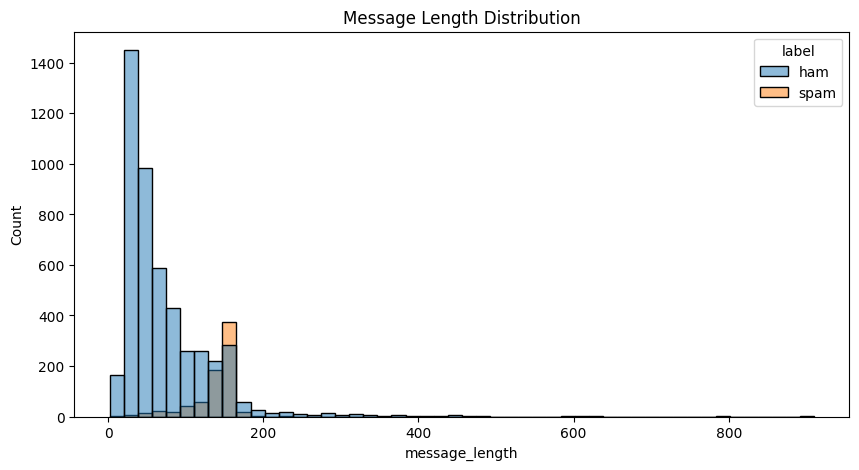

In [59]:
df["message_length"] = df["message"].apply(len)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=50
)

plt.title("Message Length Distribution")
plt.show()

In [60]:
label_counts = df["label"].value_counts()
label_percentages = df["label"].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

summary_df

,count,percentage
label,,
ham,4825,86.59
spam,747,13.41


In [61]:
df.groupby("label")["message_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4825.0,71.482487,58.440652,2.0,33.0,52.0,93.0,910.0
spam,747.0,138.670683,28.873603,13.0,133.0,149.0,157.0,223.0


In [62]:
import re
import string


def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " url ", text)
    text = re.sub(r"\d+", " number ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text



df["clean_message"] = df["message"].apply(clean_text)


df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in number a wkly comp to win fa cup...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [63]:
df["label_encoded"] = df["label"].map({
    "ham": 0,
    "spam": 1
})


df.head()

,label,message,message_length,clean_message,label_encoded
0,ham,"Go until jurong point, crazy.. Available only ...",111,go until jurong point crazy available only in ...,0
1,ham,Ok lar... Joking wif u oni...,29,ok lar joking wif u oni,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entry in number a wkly comp to win fa cup...,1
3,ham,U dun say so early hor... U c already then say...,49,u dun say so early hor u c already then say,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,nah i dont think he goes to usf he lives aroun...,0


In [64]:
from collections import Counter

spam_words = " ".join(
    df[df["label"] == "spam"]["clean_message"]
).split()

ham_words = " ".join(
    df[df["label"] == "ham"]["clean_message"]
).split()

spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

spam_common, ham_common

([('number', 3317),
  ('to', 689),
  ('a', 390),
  ('call', 362),
  ('£', 297),
  ('you', 287),
  ('your', 264),
  ('free', 221),
  ('the', 204),
  ('for', 203),
  ('now', 192),
  ('or', 192),
  ('u', 159),
  ('is', 158),
  ('txt', 152),
  ('on', 145),
  ('ur', 144),
  ('have', 135),
  ('from', 129),
  ('mobile', 125)],
 [('i', 2196),
  ('you', 1841),
  ('to', 1562),
  ('number', 1322),
  ('the', 1133),
  ('a', 1067),
  ('u', 1002),
  ('and', 849),
  ('in', 817),
  ('me', 761),
  ('my', 748),
  ('is', 735),
  ('it', 594),
  ('of', 525),
  ('for', 507),
  ('that', 489),
  ('im', 453),
  ('have', 441),
  ('but', 425),
  ('your', 414)])

In [65]:
from sklearn.model_selection import train_test_split

X = df["clean_message"]
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 4457
Test size: 1115


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(4457, 5000)
(1115, 5000)


In [67]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [68]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

Accuracy : 0.9730941704035875
Precision: 1.0
Recall   : 0.7986577181208053
F1 Score : 0.8880597014925373


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       966
           1       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



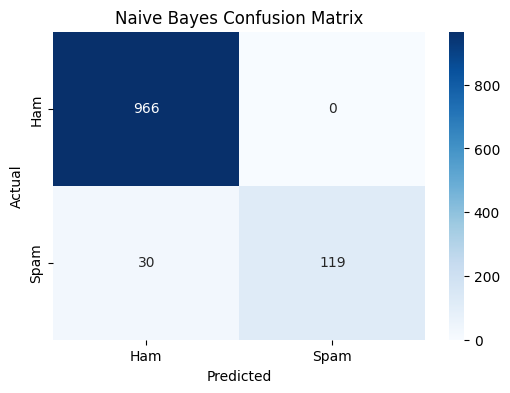

In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [74]:
results = []

for model_name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.973094,1.000000,0.798658,0.888060
1,Logistic Regression,0.976682,0.955556,0.865772,0.908451
2,Linear SVM,0.984753,0.952055,0.932886,0.942373
3,Random Forest,0.982960,1.000000,0.872483,0.931900


In [75]:
results_display = results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    results_display[col] = (results_display[col] * 100).round(2)

results_display

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,97.31,100.00,79.87,88.81
1,Logistic Regression,97.67,95.56,86.58,90.85
2,Linear SVM,98.48,95.21,93.29,94.24
3,Random Forest,98.30,100.00,87.25,93.19


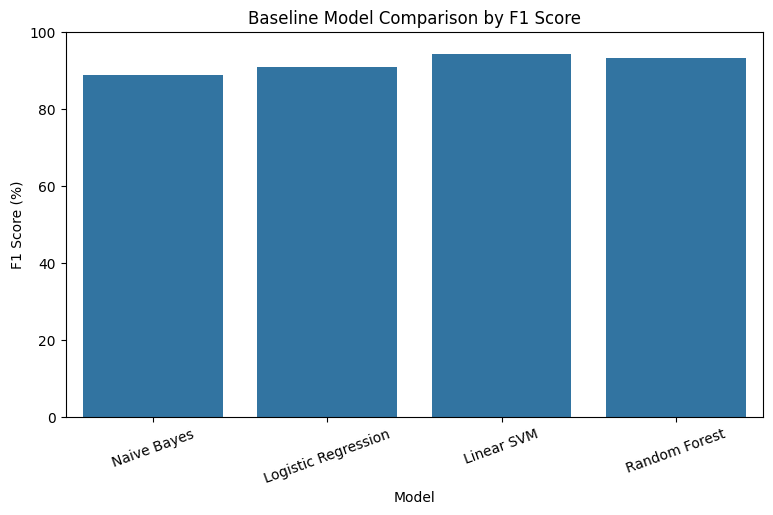

In [76]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_display,
    x="Model",
    y="F1 Score"
)

plt.title("Baseline Model Comparison by F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from keras.utils import pad_sequences

In [85]:
max_words = 10000
max_len = 100


tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(X_train)

In [86]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [87]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len
)

In [88]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(4457, 100)
(1115, 100)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from keras.utils import pad_sequences

from keras.models import Sequential
from keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [92]:
bigru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),

    Bidirectional(GRU(64, return_sequences=False)),

    Dropout(0.5),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

bigru_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

bigru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [93]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_bigru = bigru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 79ms/step - accuracy: 0.9324 - loss: 0.2009 - val_accuracy: 0.9765 - val_loss: 0.0788
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9910 - loss: 0.0332 - val_accuracy: 0.9899 - val_loss: 0.0537
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9980 - loss: 0.0093 - val_accuracy: 0.9809 - val_loss: 0.0665
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9994 - loss: 0.0048 - val_accuracy: 0.9877 - val_loss: 0.0762
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9997 - loss: 9.2665e-04 - val_accuracy: 0.9888 - val_loss: 0.0893


In [94]:
y_pred_prob_bigru = bigru_model.predict(X_test_pad)
y_pred_bigru = (y_pred_prob_bigru > 0.5).astype("int32").flatten()

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [95]:
print("Accuracy :", accuracy_score(y_test, y_pred_bigru))
print("Precision:", precision_score(y_test, y_pred_bigru))
print("Recall   :", recall_score(y_test, y_pred_bigru))
print("F1 Score :", f1_score(y_test, y_pred_bigru))

Accuracy : 0.9874439461883409
Precision: 0.9787234042553191
Recall   : 0.9261744966442953
F1 Score : 0.9517241379310345


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer # type: ignore


class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="random_normal",
            trainable=True
        )

        self.b = self.add_weight(
            name="attention_bias",
            shape=(input_shape[1], 1),
            initializer="zeros",
            trainable=True
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        score = tf.nn.tanh(tf.matmul(inputs, self.W) + self.b)
        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = inputs * attention_weights
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

In [ ]:
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.layers import Input # type: ignore

input_layer = Input(shape=(max_len,))

embedding_layer = Embedding(
    input_dim=max_words,
    output_dim=128
)(input_layer)

bigru_layer = Bidirectional(
    GRU(64, return_sequences=True)
)(embedding_layer)

attention_layer = AttentionLayer()(bigru_layer)

dropout_layer = Dropout(0.5)(attention_layer)

dense_layer = Dense(32, activation="relu")(dropout_layer)
dropout_layer_2 = Dropout(0.3)(dense_layer)

output_layer = Dense(1, activation="sigmoid")(dropout_layer_2)

attention_model = Model(
    inputs=input_layer,
    outputs=output_layer
)

attention_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

attention_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 100, 128)       │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_1               │ (None, 128)            │           228 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,358,885 (5.18 MB)

 Trainable params: 1,358,885 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
early_stop_attention = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_attention = attention_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop_attention],
    verbose=1
)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.9229 - loss: 0.2211 - val_accuracy: 0.9686 - val_loss: 0.0829
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.9826 - loss: 0.0628 - val_accuracy: 0.9821 - val_loss: 0.0581
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.9944 - loss: 0.0250 - val_accuracy: 0.9854 - val_loss: 0.0606
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.9843 - val_loss: 0.0639
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9989 - loss: 0.0034 - val_accuracy: 0.9821 - val_loss: 0.0976


In [99]:
y_pred_prob_attention = attention_model.predict(X_test_pad)
y_pred_attention = (y_pred_prob_attention > 0.5).astype("int32").flatten()

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step


In [100]:
print("Accuracy :", accuracy_score(y_test, y_pred_attention))
print("Precision:", precision_score(y_test, y_pred_attention))
print("Recall   :", recall_score(y_test, y_pred_attention))
print("F1 Score :", f1_score(y_test, y_pred_attention))

Accuracy : 0.9811659192825112
Precision: 0.9571428571428572
Recall   : 0.8993288590604027
F1 Score : 0.9273356401384083


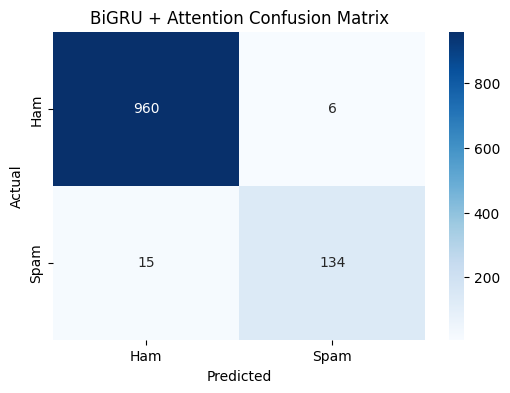

In [101]:
cm_attention = confusion_matrix(y_test, y_pred_attention)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_attention,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BiGRU + Attention Confusion Matrix")
plt.show()

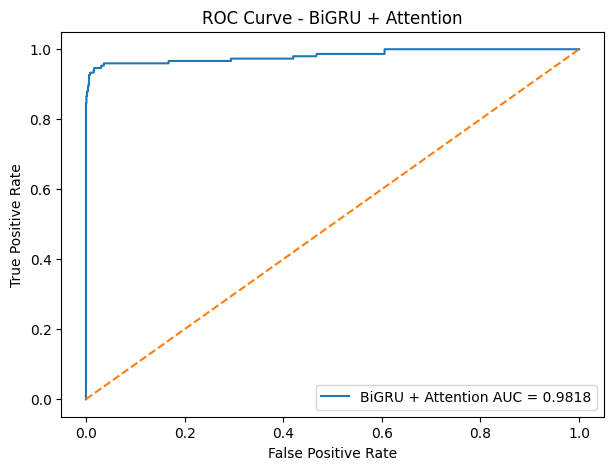

In [102]:
from sklearn.metrics import roc_curve, auc

fpr_attention, tpr_attention, thresholds_attention = roc_curve(
    y_test,
    y_pred_prob_attention
)

auc_attention = auc(fpr_attention, tpr_attention)

plt.figure(figsize=(7, 5))
plt.plot(fpr_attention, tpr_attention, label=f"BiGRU + Attention AUC = {auc_attention:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BiGRU + Attention")
plt.legend()
plt.show()

In [103]:
import os

os.makedirs("../outputs/models", exist_ok=True)

attention_model.save("../outputs/models/bigru_attention_model.keras")

In [104]:
import pickle

with open("../outputs/models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [105]:
config = {
    "max_len": max_len,
    "max_words": max_words
}

with open("../outputs/models/config.pkl", "wb") as f:
    pickle.dump(config, f)